In [5]:
# ==========================================
# FILE 2: LIGHTGBM TRAINING (FIXED)
# Path: .../1.MachineLearning/train_lgbm.py
# ==========================================

import pandas as pd
import numpy as np
import re
import unicodedata
import time
import warnings
import os
import joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score
from lightgbm import LGBMClassifier
from scipy.sparse import hstack, csr_matrix

import lightgbm as lgb
from tqdm.auto import tqdm
tqdm.pandas()

# ==========================================
# SETUP PATHS
# ==========================================
DATA_DIR = r"D:\Study\HK6\CS221-NLP\CS221\Data\Clean"
MODEL_DIR = r"D:\Study\HK6\CS221-NLP\CS221\Notebooks\Phase_3\1.MachineLearning\MachineLearning"
TRAIN_PATH = f"{DATA_DIR}/train_clean.csv"
VAL_PATH = f"{DATA_DIR}/val_clean.csv"
TEST_PATH = f"{DATA_DIR}/test_clean.csv"

if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)

# ==========================================
# 1. LOAD DATA
# ==========================================
print("Loading data...")
start_load = time.time()

df_train = pd.read_csv(TRAIN_PATH)
df_val = pd.read_csv(VAL_PATH)
df_test = pd.read_csv(TEST_PATH)
df_train_full = pd.concat([df_train, df_val], ignore_index=True)

le = LabelEncoder()
y_train_full = le.fit_transform(df_train_full['label'])
y_test = le.transform(df_test['label'])
class_names = le.classes_

print(f"Data loaded in {time.time() - start_load:.2f} seconds.")

# ==========================================
# 2. TEXT PREPROCESSING
# ==========================================
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
    text = text.replace('<url>', ' special_token_url ')
    text = text.replace('<username>', ' special_token_user ')
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'[^\w\s:]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Preprocessing data...")
start_preprocess = time.time()

X_train_full_text = df_train_full['text'].progress_apply(preprocess_text)
X_test_text = df_test['text'].progress_apply(preprocess_text)

print(f"Preprocessing done in {time.time() - start_preprocess:.2f} seconds.")

# ==========================================
# 3. FEATURE ENGINEERING
# ==========================================
print("Extracting features...")
start_feat = time.time()

tfidf_word_vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=10000, sublinear_tf=True, min_df=2)
tfidf_char_vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(3, 5), max_features=1000, sublinear_tf=True)

def get_features_adv(text_series, vec_word, vec_char, fit=False):
    if fit:
        tfidf_word = vec_word.fit_transform(text_series)
        tfidf_char = vec_char.fit_transform(text_series)
    else:
        tfidf_word = vec_word.transform(text_series)
        tfidf_char = vec_char.transform(text_series)
    
    word_counts = text_series.apply(lambda x: len(x.split())).values
    word_counts_sparse = csr_matrix(word_counts).T
    avg_word_len = text_series.apply(lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0).values
    avg_word_len_sparse = csr_matrix(avg_word_len).T
    
    return hstack([tfidf_word, tfidf_char, word_counts_sparse, avg_word_len_sparse])

X_train_features = get_features_adv(X_train_full_text, tfidf_word_vectorizer, tfidf_char_vectorizer, fit=True)
X_test_features = get_features_adv(X_test_text, tfidf_word_vectorizer, tfidf_char_vectorizer, fit=False)

if hasattr(X_train_features, "tocsr"): X_train_features = X_train_features.tocsr()
if hasattr(X_test_features, "tocsr"): X_test_features = X_test_features.tocsr()

print(f"Features extracted in {time.time() - start_feat:.2f} seconds. Shape: {X_train_features.shape}")

Loading data...
Data loaded in 0.28 seconds.
Preprocessing data...


100%|██████████| 7415/7415 [00:00<00:00, 27074.94it/s]


Preprocessing done in 1.97 seconds.
Extracting features...
Features extracted in 54.66 seconds. Shape: (41098, 11002)


In [ ]:
# ==========================================
# 4. MANUAL TRAINING FOR LIGHTGBM
# ==========================================
print("\n=========================")
print("TRAINING LIGHTGBM")
print("=========================")

X_train_manual, X_val_manual, y_train_manual, y_val_manual = train_test_split(
    X_train_features, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full
)

lgbm_params = {
    'objective': 'multiclass', 'metric': 'multi_logloss', 'num_class': len(class_names),
    'n_estimators': 2000, 'learning_rate': 0.1, 'num_leaves': 31, 'max_depth': -1,
    'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 0.1, 'class_weight': 'balanced',
    'random_state': 42, 'n_jobs': -1, 'verbose': -1
}

print(f"Training LGBM on {X_train_manual.shape[0]} samples...")
model_lgbm = LGBMClassifier(**lgbm_params)

start_train = time.time()

model_lgbm.fit(
    X_train_manual, y_train_manual,
    eval_set=[(X_val_manual, y_val_manual)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=100)]
)

train_duration = time.time() - start_train
print(f"\nTraining finished in {train_duration:.2f} seconds ({train_duration/60:.2f} minutes).")

# ==========================================
# 5. EVALUATION (INFERENCE TIME)
# ==========================================
print("\n=========================")
print("FINAL EVALUATION")
print("=========================")

# Tính thời gian inference (predict)
start_inf = time.time()
y_pred_lgbm = model_lgbm.predict(X_test_features)
end_inf = time.time()

inf_time_total = end_inf - start_inf
# --- SỬA LỖI Ở ĐÂY: Dùng shape[0] thay vì len() ---
num_samples = X_test_features.shape[0]
inf_time_per_sample_ms = (inf_time_total / num_samples) * 1000

f1_lgbm = f1_score(y_test, y_pred_lgbm, average='macro')

print(f"Test F1-Macro: {f1_lgbm * 100:.2f}%")
print(f"Training Time: {train_duration:.2f} seconds")
print(f"Inference Time: {inf_time_total:.4f} seconds")
print(f"Speed: {inf_time_per_sample_ms:.4f} ms/sample")

print("\nClassification Report (LightGBM):")
print(classification_report(y_test, y_pred_lgbm, target_names=class_names, digits=4))

# ==========================================
# 6. SAVE MODEL
# ==========================================
print("\nSaving model...")
joblib.dump(model_lgbm, f"{MODEL_DIR}/lgbm_model.pkl")
joblib.dump(tfidf_word_vectorizer, f"{MODEL_DIR}/tfidf_word.pkl")
joblib.dump(tfidf_char_vectorizer, f"{MODEL_DIR}/tfidf_char.pkl")
joblib.dump(le, f"{MODEL_DIR}/label_encoder.pkl")
print("Saved to:", MODEL_DIR)

total_time = time.time() - start_load
print(f"\nTOTAL EXECUTION TIME: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")

Biến y_pred_lgbm không có trong RAM, tự động load lại model lgbm_model.pkl...


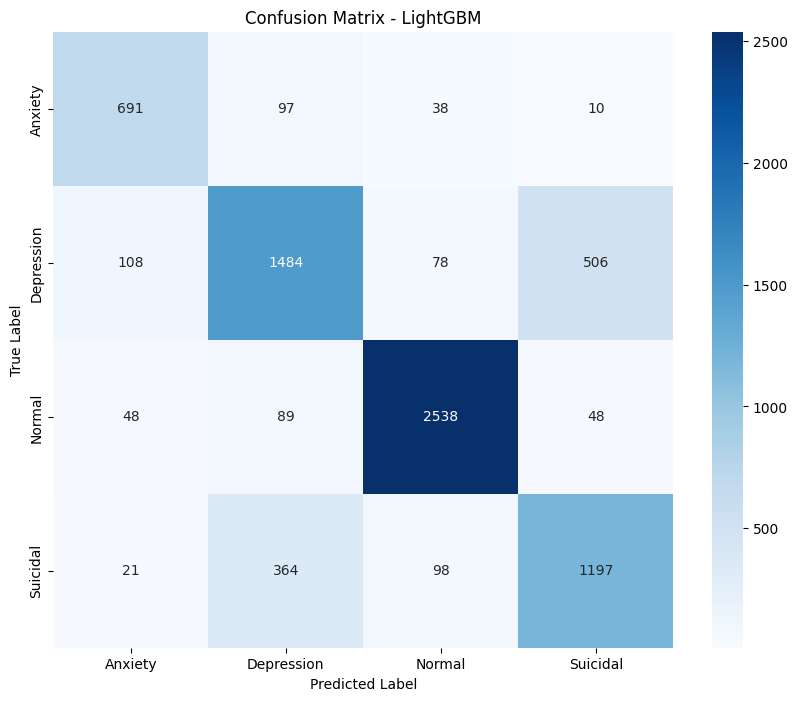

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import joblib

try:
    if 'y_pred_lgbm' not in locals():
        loaded_model = joblib.load(f"{MODEL_DIR}/lgbm_model.pkl")
        y_pred_lgbm = loaded_model.predict(X_test_features)
        
    cm = confusion_matrix(y_test, y_pred_lgbm)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    
    plt.title('Confusion Matrix - LightGBM')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()